# Fruktsamhet, befolkningstäthet och konjunktur
Kör alla celler uppifrån och ned. Kommunjämförelsen använder kvinnors summerade fruktsamhet och SCB:s faktiska riksserie. De nya blocken skapar ett gemensamt underlag med en rad per kommun och år. De utför ännu ingen regelutvinning eller avvikelsemodell.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# Läs och skriv enbart i Dennis egen mapp.
kandidater = [Path.cwd(), Path.cwd() / "Dennis lek och bus"]
min_mapp = next((p for p in kandidater if (p / "FertilitetPerKommunNY.csv").is_file()), None)
assert min_mapp is not None, "Kör notebooken från din mapp eller projektroten."
data = min_mapp


In [2]:
fruktsamhet = pd.read_csv(
    data / "FertilitetPerKommunNY.csv",
    sep=";",
    na_values=[".."]
)

konjunktur = pd.read_csv(
    data / "konjunkturklockanNY.csv",
    sep=";",
    na_values=[".."]
)

tathet = pd.read_csv(
    data / "befolkningstathetNY.csv",
    encoding="utf-8-sig",
    dtype={"Kommunkod": "string"},
    na_values=[".."]
)
# SCB:s faktiska riksserie, inte ett medelvärde av kommunerna.
riket = pd.read_csv(data / "Fruktbarhet_riket.NYcsv", encoding="utf-8-sig", na_values=[".."])
riket = riket.loc[riket["kön"].eq("kvinnor")].rename(
    columns={"Summerad fruktsamhet, antal": "Värde"}
).copy()
assert riket["region"].eq("00 Riket").all()
assert not riket.duplicated("år").any()


In [3]:
display(fruktsamhet.head())
display(konjunktur.head())
display(tathet.head())

print("Fruktsamhet:", fruktsamhet.shape)
print("Konjunktur:", konjunktur.shape)
print("Befolkningstäthet:", tathet.shape)

,region,kön,tabellinnehåll,år,Värde
0,Upplands Väsby,män,Antal,2000,1.43
1,Upplands Väsby,män,Antal,2001,1.52
2,Upplands Väsby,män,Antal,2002,1.51
3,Upplands Väsby,män,Antal,2003,1.64
4,Upplands Väsby,män,Antal,2004,1.56


,indikator,tabellinnehåll,månad,Värde
0,BNP-indikator månad,Konjunkturläge,2000M01,-1.07
1,BNP-indikator månad,Konjunkturläge,2000M02,-0.84
2,BNP-indikator månad,Konjunkturläge,2000M03,-0.59
3,BNP-indikator månad,Konjunkturläge,2000M04,-0.29
4,BNP-indikator månad,Konjunkturläge,2000M05,0.01


,Kommunkod,Kommun,Kon,År,Befolkningstäthet (invånare per kvkm),Folkmängd
0,0114,Upplands Väsby,1+2,2000,498.6,37576.0
1,0114,Upplands Väsby,1+2,2001,497.9,37524.0
2,0114,Upplands Väsby,1+2,2002,496.8,37444.0
3,0114,Upplands Väsby,1+2,2003,496.2,37397.0
4,0114,Upplands Väsby,1+2,2004,497.8,37517.0


Fruktsamhet: (15080, 5)
Konjunktur: (8960, 4)
Befolkningstäthet: (7540, 6)


In [4]:
fruktsamhet = fruktsamhet.loc[
    fruktsamhet["kön"] == "kvinnor"
].copy()

fruktsamhet["Värde"] = pd.to_numeric(
    fruktsamhet["Värde"], errors="raise"
)

print("Antal kommuner:", fruktsamhet["region"].nunique())
print("Antal rader:", len(fruktsamhet))
print("Saknade värden:", fruktsamhet["Värde"].isna().sum())

assert not fruktsamhet.duplicated(["region", "år"]).any()

Antal kommuner: 290
Antal rader: 7540
Saknade värden: 204


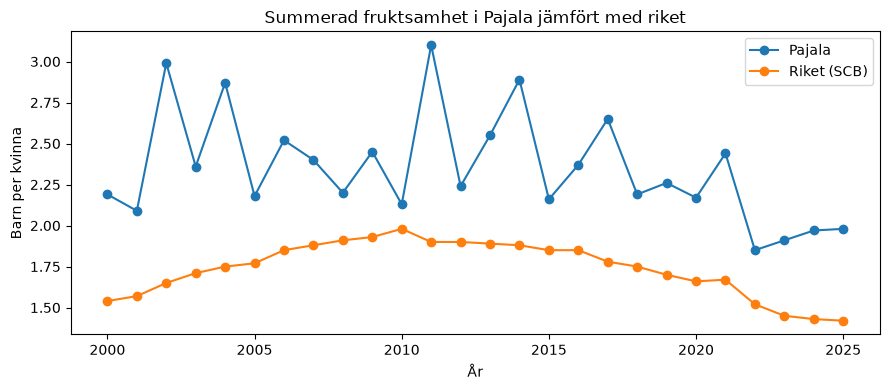

In [5]:
kommun = "Pajala"


urval = (
    fruktsamhet.loc[fruktsamhet["region"] == kommun]
    .sort_values("år")
)


ax = urval.plot(
    x="år",
    y="Värde",
    marker="o",
    label=kommun,
    figsize=(9, 4)
)

riket.plot(
    x="år",
    y="Värde",
    marker="o",
    label="Riket (SCB)",
    ax=ax
)

ax.set_title(f"Summerad fruktsamhet i {kommun} jämfört med riket")
ax.set_ylabel("Barn per kvinna")
ax.set_xlabel("År")
ax.legend()
plt.tight_layout()
plt.show()

## Koppla fruktsamhet till kommunkod och befolkningstäthet
Kommunfilen saknar kommunkod. Vi hämtar koden via en kontrollerad, entydig namnmatchning mot täthetsfilen. Därefter kopplas uppgifterna på kommunkod och år. Saknade fruktsamhetsvärden behålls.

In [6]:
for tabell, arkolumn in [(fruktsamhet, "år"), (riket, "år"), (tathet, "År")]:
    tabell[arkolumn] = pd.to_numeric(tabell[arkolumn], errors="raise").astype(int)
riket["Värde"] = pd.to_numeric(riket["Värde"], errors="raise")
for kolumn in ["Befolkningstäthet (invånare per kvkm)", "Folkmängd"]:
    tathet[kolumn] = pd.to_numeric(tathet[kolumn], errors="raise")
assert tathet["Kommunkod"].str.fullmatch(r"\d{4}").all()
assert not tathet.duplicated(["Kommunkod", "År"]).any()

namnnyckel = tathet[["Kommunkod", "Kommun"]].drop_duplicates().copy()
namnnyckel["namnnyckel"] = namnnyckel["Kommun"].str.strip().str.casefold()
assert not namnnyckel.duplicated("namnnyckel").any()
assert not namnnyckel.duplicated("Kommunkod").any()
kommun_data = fruktsamhet.rename(columns={"år": "ar", "Värde": "fruktsamhet"}).copy()
kommun_data["namnnyckel"] = kommun_data["region"].str.strip().str.casefold()
kommun_data = kommun_data.merge(namnnyckel, on="namnnyckel", how="left", validate="many_to_one")
assert kommun_data["Kommunkod"].notna().all(), "Något kommunnamn saknar matchning."
kommun_data = kommun_data[["Kommunkod", "Kommun", "ar", "fruktsamhet"]]

tathet_ar = tathet.rename(columns={"År": "ar", "Befolkningstäthet (invånare per kvkm)": "befolkningstathet", "Folkmängd": "folkmangd"})
kommun_data = kommun_data.merge(
    tathet_ar[["Kommunkod", "ar", "befolkningstathet", "folkmangd"]],
    on=["Kommunkod", "ar"], how="left", validate="one_to_one", indicator=True
)
assert kommun_data["_merge"].eq("both").all()
kommun_data = kommun_data.drop(columns="_merge")
kommun_data = kommun_data.merge(
    riket[["år", "Värde"]].rename(columns={"år": "ar", "Värde": "riket_fruktsamhet"}),
    on="ar", how="left", validate="many_to_one"
)
assert kommun_data["riket_fruktsamhet"].notna().all()
kommun_data["skillnad_mot_riket"] = kommun_data["fruktsamhet"] - kommun_data["riket_fruktsamhet"]

# Exakt föregående kalenderår, även om år saknas i en framtida fil.
foregaende = kommun_data[["Kommunkod", "ar", "fruktsamhet"]].copy()
foregaende["ar"] += 1
foregaende = foregaende.rename(columns={"fruktsamhet": "fruktsamhet_foregaende_ar"})
kommun_data = kommun_data.merge(foregaende, on=["Kommunkod", "ar"], how="left", validate="one_to_one")
kommun_data["forandring_fruktsamhet"] = kommun_data["fruktsamhet"] - kommun_data["fruktsamhet_foregaende_ar"]
display(kommun_data.head())


,Kommunkod,Kommun,ar,fruktsamhet,befolkningstathet,folkmangd,riket_fruktsamhet,skillnad_mot_riket,fruktsamhet_foregaende_ar,forandring_fruktsamhet
0,0114,Upplands Väsby,2000,1.54,498.6,37576.0,1.54,0.00,NaN,NaN
1,0114,Upplands Väsby,2001,1.59,497.9,37524.0,1.57,0.02,1.54,0.05
2,0114,Upplands Väsby,2002,1.65,496.8,37444.0,1.65,0.00,1.59,0.06
3,0114,Upplands Väsby,2003,1.81,496.2,37397.0,1.71,0.10,1.65,0.16
4,0114,Upplands Väsby,2004,1.69,497.8,37517.0,1.75,-0.06,1.81,-0.12


## Fast indelning efter befolkningstäthet 2003
Medianen 2003 används som en föreslagen projektindelning för utfallsår 2004–2025. Kommuner under medianen får lägre täthet, övriga högre täthet. Detta är inte en officiell indelning i stad och landsbygd. Behåll även de numeriska täthetsvärdena för senare känslighetsanalys.

In [7]:
referensar = 2003
referens = tathet_ar.loc[tathet_ar["ar"].eq(referensar), ["Kommunkod", "befolkningstathet"]].copy()
assert not referens.duplicated("Kommunkod").any()
assert referens["befolkningstathet"].notna().all()
assert referens["befolkningstathet"].gt(0).all()
grans = referens["befolkningstathet"].median()
referens = referens.rename(columns={"befolkningstathet": "befolkningstathet_2003"})
referens["kommuntyp"] = referens["befolkningstathet_2003"].map(
    lambda x: "Lägre täthet" if x < grans else "Högre täthet"
)
kommun_data = kommun_data.merge(referens, on="Kommunkod", how="left", validate="many_to_one")
assert kommun_data["kommuntyp"].notna().all()
print(f"Gruppgräns: {grans:.1f} invånare/km² år {referensar}")
display(referens.groupby("kommuntyp").size().rename("antal_kommuner"))


Gruppgräns: 26.4 invånare/km² år 2003


kommuntyp
Högre täthet    146
Lägre täthet    144
Name: antal_kommuner, dtype: int64

## Konjunktur per år och tidsfördröjning
Vi använder konjunkturläge för BNP-indikator månad, hushållens konsumtion och sysselsättning. Årsmedel beräknas endast med tolv observerade månader. Lagg 1 betyder att fruktsamhet år t jämförs med konjunktur år t−1. Konjunkturen är gemensam för alla kommuner. Värdena är standardiserade konjunkturlägen, inte tillväxttal eller sysselsättningsgrader.

In [8]:
indikatorer = {"BNP-indikator månad": "bnp", "Hushållens konsumtion": "konsumtion", "Sysselsättning": "sysselsattning"}
ekonomi = konjunktur.loc[
    konjunktur["tabellinnehåll"].eq("Konjunkturläge") & konjunktur["indikator"].isin(indikatorer)
].copy()
ekonomi["datum"] = pd.to_datetime(ekonomi["månad"], format="%YM%m", errors="raise")
ekonomi["ar"] = ekonomi["datum"].dt.year
ekonomi["Värde"] = pd.to_numeric(ekonomi["Värde"], errors="raise")
assert not ekonomi.duplicated(["indikator", "datum"]).any()
ekonomi = ekonomi.loc[ekonomi["ar"].between(2000, 2025)]
arskontroll = ekonomi.groupby(["ar", "indikator"])["Värde"].agg(medel="mean", antal_manader="count").reset_index()
arskontroll.loc[arskontroll["antal_manader"].ne(12), "medel"] = float("nan")
konjunktur_ar = arskontroll.pivot(index="ar", columns="indikator", values="medel").rename(columns=indikatorer).reset_index()
konjunktur_ar.columns.name = None

analysdata = kommun_data.copy()
for lagg in [0, 1, 2]:
    laggad = konjunktur_ar.copy()
    laggad["ar"] += lagg
    laggad = laggad.rename(columns={namn: f"{namn}_lag{lagg}" for namn in indikatorer.values()})
    analysdata = analysdata.merge(laggad, on="ar", how="left", validate="many_to_one")
analysdata = analysdata.loc[analysdata["ar"].between(2004, 2025)].sort_values(["Kommunkod", "ar"]).reset_index(drop=True)
assert not analysdata.duplicated(["Kommunkod", "ar"]).any()
display(arskontroll.loc[arskontroll["antal_manader"].ne(12)])
display(analysdata.head())
print(f"Analystabell: {len(analysdata)} rader, {analysdata['Kommunkod'].nunique()} kommuner")


,ar,indikator,medel,antal_manader
2,2000,Sysselsättning,NaN,0


,Kommunkod,Kommun,ar,fruktsamhet,befolkningstathet,folkmangd,riket_fruktsamhet,skillnad_mot_riket,fruktsamhet_foregaende_ar,forandring_fruktsamhet,...,kommuntyp,bnp_lag0,konsumtion_lag0,sysselsattning_lag0,bnp_lag1,konsumtion_lag1,sysselsattning_lag1,bnp_lag2,konsumtion_lag2,sysselsattning_lag2
0,0114,Upplands Väsby,2004,1.69,497.8,37517.0,1.75,-0.06,1.81,-0.12,...,Högre täthet,-0.259167,-0.929167,-0.995833,-0.925000,-0.553333,-0.116667,-0.423333,-0.244167,0.509167
1,0114,Upplands Väsby,2005,1.81,499.2,37624.0,1.77,0.04,1.69,0.12,...,Högre täthet,0.215000,-0.122500,-1.293333,-0.259167,-0.929167,-0.995833,-0.925000,-0.553333,-0.116667
2,0114,Upplands Väsby,2006,1.80,502.2,37848.0,1.85,-0.05,1.81,-0.01,...,Högre täthet,1.423333,0.857500,-0.198333,0.215000,-0.122500,-1.293333,-0.259167,-0.929167,-0.995833
3,0114,Upplands Väsby,2007,1.93,504.9,38055.0,1.88,0.05,1.80,0.13,...,Högre täthet,2.357500,1.937500,1.605833,1.423333,0.857500,-0.198333,0.215000,-0.122500,-1.293333
4,0114,Upplands Väsby,2008,1.79,507.5,38248.0,1.91,-0.12,1.93,-0.14,...,Högre täthet,1.065833,0.487500,1.950833,2.357500,1.937500,1.605833,1.423333,0.857500,-0.198333


Analystabell: 6380 rader, 290 kommuner


## Bortfall och kommungrupper jämfört med riket
Grupplinjerna är ovägda medel av tillgängliga kommunvärden. De beskriver en genomsnittlig kommun i gruppen, inte ett befolkningsvägt fruktsamhetsmått. Rikets linje är SCB:s separata riksserie. Saknade observationer kan ändra vilka kommuner som ingår ett visst år.

Kompletta rader för förändring och tre indikatorer med lagg 1: 6153


,kommuner,kommun_ar,observerad_fruktsamhet,saknade_fruktsamhet,bortfall_procent
kommuntyp,,,,,
Högre täthet,146,3212,3200,12,0.37
Lägre täthet,144,3168,2995,173,5.46


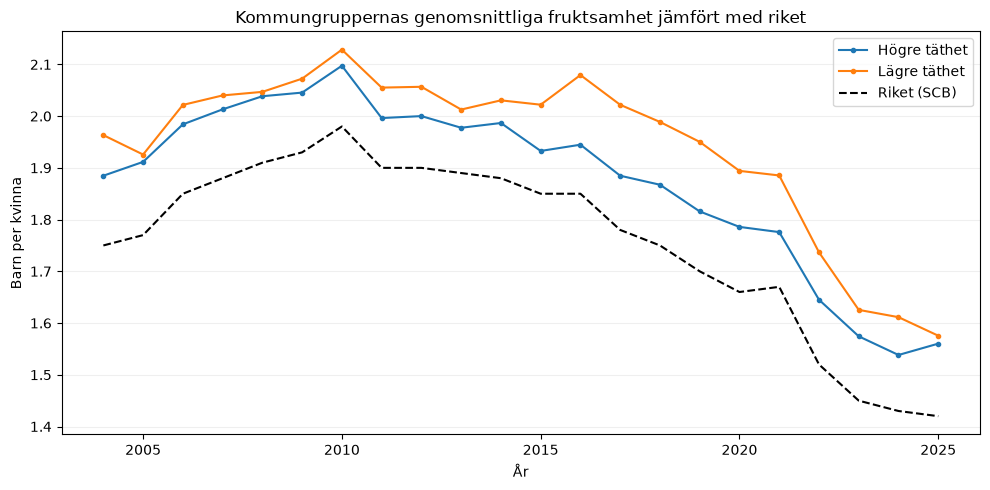

In [9]:
kontroll = analysdata.groupby("kommuntyp").agg(
    kommuner=("Kommunkod", "nunique"), kommun_ar=("ar", "size"),
    observerad_fruktsamhet=("fruktsamhet", "count")
)
kontroll["saknade_fruktsamhet"] = kontroll["kommun_ar"] - kontroll["observerad_fruktsamhet"]
kontroll["bortfall_procent"] = 100 * kontroll["saknade_fruktsamhet"] / kontroll["kommun_ar"]
krav = ["forandring_fruktsamhet", "bnp_lag1", "konsumtion_lag1", "sysselsattning_lag1"]
print("Kompletta rader för förändring och tre indikatorer med lagg 1:", analysdata[krav].notna().all(axis=1).sum())
display(kontroll.round(2))

gruppmedel = analysdata.groupby(["ar", "kommuntyp"])["fruktsamhet"].mean().unstack()
ax = gruppmedel.plot(figsize=(10, 5), marker="o", markersize=3)
riksurval = riket.loc[riket["år"].between(2004, 2025)].sort_values("år")
ax.plot(riksurval["år"], riksurval["Värde"], color="black", linestyle="--", label="Riket (SCB)")
ax.set_title("Kommungruppernas genomsnittliga fruktsamhet jämfört med riket")
ax.set_xlabel("År")
ax.set_ylabel("Barn per kvinna")
ax.grid(axis="y", alpha=0.2)
ax.legend()
plt.tight_layout()
plt.show()


## Spara det gemensamma underlaget
När du kör nästa cell sparas analystabellen och datakontrollen i `Dennis lek och bus/resultat`. Originaldata ändras inte. Körningen ersätter tidigare exporter med samma namn. Kommunkod ska läsas som text vid nästa import.

Nästa analyssteg är att fastställa en kursrelevant regelalgoritm, kategorisera variabler på utvecklingsperioden och utvärdera regler över tid. Diagrammen här visar ingen konjunktureffekt. Täthetsgrupper, geografiska gränsändringar och det större bortfallet bland små kommuner måste beaktas. Framtida år har redan visats i diagram och ska inte beskrivas som helt osedda testdata.

In [10]:
resultatmapp = min_mapp / "resultat_NY"
resultatmapp.mkdir(exist_ok=True)
analysdata.to_csv(resultatmapp / "analysunderlag_2004_2025.csv", index=False, encoding="utf-8-sig")
kontroll.to_csv(resultatmapp / "datakontroll_per_grupp.csv", encoding="utf-8-sig")
arskontroll.to_csv(resultatmapp / "konjunktur_datatackning.csv", index=False, encoding="utf-8-sig")
print(f"Sparat i {resultatmapp}")


Sparat i /Users/dennis/DataMining-project/Dennis lek och bus/resultat_NY


## Granska NY-filerna inför ARM
Originalfilerna bevaras. Filtrering betyder här ett separat analysurval. Män tas bort från fruktsamhetsanalysen eftersom utfallet gäller kvinnor. Tätheten avser däremot hela befolkningen och ska behållas. Riksserien är en referens, inte en extra kommuntransaktion.

Vi granskar alla 14 konjunkturindikatorer innan ett slutligt indikatorurval beslutas. Saknade uppgifter får inte bli noll eller kategorin oförändrat. Ovanliga men möjliga fruktsamhetsvärden tas inte bort automatiskt.

In [11]:
# Kontrollera råfilernas nycklar och bortfall innan nya urval görs.
kommun_raw = pd.read_csv(data / "FertilitetPerKommunNY.csv", sep=";", na_values=[".."])
konj_raw = pd.read_csv(data / "konjunkturklockanNY.csv", sep=";", na_values=[".."])
riket_kvinnor = pd.read_csv(data / "Fruktbarhet_riket_kvinnorNY.csv", header=None,
    names=["region", "kön", "år", "Värde"], na_values=[".."])
pd.testing.assert_series_equal(
    riket.set_index("år")["Värde"].sort_index(),
    riket_kvinnor.set_index("år")["Värde"].sort_index(), check_names=False, check_dtype=False
)
assert not kommun_raw.duplicated(["region", "kön", "år"]).any()
assert not konj_raw.duplicated(["indikator", "tabellinnehåll", "månad"]).any()
assert not tathet.duplicated(["Kommunkod", "År"]).any()
print("Unika nycklar kontrollerade. De två riksfilerna ger samma kvinnoserie.")
display(kommun_raw.groupby("kön")["Värde"].agg(rader="size", observerade="count"))

# Alla indikatorer och båda måtten granskas, även de som inte valts ovan.
konj_raw["ar"] = pd.to_datetime(konj_raw["månad"], format="%YM%m").dt.year
konj_raw["Värde"] = pd.to_numeric(konj_raw["Värde"], errors="raise")
konj_tackning = konj_raw.groupby(["indikator", "tabellinnehåll", "ar"])["Värde"].agg(
    rader="size", observerade="count"
).reset_index()
konj_tackning["saknade"] = konj_tackning["rader"] - konj_tackning["observerade"]
display(konj_tackning.loc[konj_tackning["observerade"].ne(12)])

# Flagga orimliga eller geografiskt svårtolkade värden, utan att radera dem.
geografiska_flaggor = tathet.loc[
    tathet["Befolkningstäthet (invånare per kvkm)"].le(0)
    | tathet["Folkmängd"].le(0)
    | (tathet["Kommunkod"].eq("0330") & tathet["År"].lt(2003))
].copy()
display(geografiska_flaggor)
print("Fruktsamhet kvinnor, min/max:", fruktsamhet["Värde"].min(), fruktsamhet["Värde"].max())


Unika nycklar kontrollerade. De två riksfilerna ger samma kvinnoserie.


,rader,observerade
kön,,
kvinnor,7540,7336
män,7540,7330


,indikator,tabellinnehåll,ar,rader,observerade,saknade
0,Arbetade timmar,Förändring från föregående period,2000,12,0,12
1,Arbetade timmar,Förändring från föregående period,2001,12,11,1
26,Arbetade timmar,Förändring från föregående period,2026,8,7,1
27,Arbetade timmar,Konjunkturläge,2000,12,0,12
53,Arbetade timmar,Konjunkturläge,2026,8,7,1
54,BNP kvartal,Förändring från föregående period,2000,12,9,3
80,BNP kvartal,Förändring från föregående period,2026,8,6,2
107,BNP kvartal,Konjunkturläge,2026,8,6,2
108,BNP-indikator månad,Förändring från föregående period,2000,12,11,1
134,BNP-indikator månad,Förändring från föregående period,2026,8,7,1


,Kommunkod,Kommun,Kon,År,Befolkningstäthet (invånare per kvkm),Folkmängd
728,0330,Knivsta,1+2,2000,0.0,0.0
729,0330,Knivsta,1+2,2001,0.0,0.0
730,0330,Knivsta,1+2,2002,44.4,12586.0


Fruktsamhet kvinnor, min/max: 0.96 3.15


## Separat ARM-urval och bortfallslogg
Startförslaget är utfallsår 2004–2025 med föregående års konsumtion, sysselsättning och BNP-indikator. Åren före 2004 behålls som historik för referensår och tidsfördröjningar. År 2026 i konjunkturfilen ingår inte eftersom fruktsamhetsdata slutar 2025.

Bara rader med de variabler som denna analys behöver tas med i ARM-urvalet. Övriga rader sparas med förklaring. Ett annat indikatorurval kan ge ett annat bortfall. Radera alltså inte rader som saknar någon av samtliga 14 indikatorer som generell regel.

Ingen kommun tas bort enbart för låg befolkning eller ett extremvärde. Geografiska förändringar, bland annat Knivsta/Uppsala och Lidingö/Vaxholm, kräver en separat känslighetskontroll. Att börja 2004 löser inte alla gränsändringar.

In [12]:
arm_krav = ["forandring_fruktsamhet", "kommuntyp", "konsumtion_lag1", "sysselsattning_lag1", "bnp_lag1"]
arm_mask = analysdata[arm_krav].notna().all(axis=1)
arm_underlag = analysdata.loc[arm_mask].copy()
arm_bortfall = analysdata.loc[~arm_mask].copy()
arm_bortfall["saknade_variabler"] = arm_bortfall[arm_krav].apply(
    lambda rad: ", ".join(rad.index[rad.isna()]), axis=1
)
assert len(arm_underlag) + len(arm_bortfall) == len(analysdata)
assert not arm_underlag.duplicated(["Kommunkod", "ar"]).any()
print(f"Hela analystabellen: {len(analysdata)} kommun–år")
print(f"ARM-starturval: {len(arm_underlag)}; exkluderade rader: {len(arm_bortfall)}")
display(arm_bortfall.groupby(["kommuntyp", "saknade_variabler"]).size().rename("antal_rader"))

resultatmapp = min_mapp / "resultat_NY"
resultatmapp.mkdir(exist_ok=True)
arm_underlag.to_csv(resultatmapp / "arm_underlag_lag1.csv", index=False, encoding="utf-8-sig")
arm_bortfall.to_csv(resultatmapp / "arm_bortfall_lag1.csv", index=False, encoding="utf-8-sig")
konj_tackning.to_csv(resultatmapp / "konjunktur_tackning_alla_indikatorer.csv", index=False, encoding="utf-8-sig")
geografiska_flaggor.to_csv(resultatmapp / "geografiska_flaggor.csv", index=False, encoding="utf-8-sig")


Hela analystabellen: 6380 kommun–år
ARM-starturval: 6153; exkluderade rader: 227


kommuntyp     saknade_variabler     
Högre täthet  forandring_fruktsamhet     18
Lägre täthet  forandring_fruktsamhet    209
Name: antal_rader, dtype: int64